# **암진단 모델 개선**
- scikit-learn dataset중 하나인 유방암 데이터를 사용하여 분류 모델링
- RandomForest를 사용하여 파라메터 서칭을 진행하며 베이스라인 모델 보다 개선이 되는 모델을 만드는 것이 목적

**베이스라인 모델**  
- train_test_split에 아래 파라메터를 적용한 y_test기준  
- test_size=0.3, random_state=42, stratify 적용한 test데이터 기준
- LogisticRegression 모델을 사용
- 평가지표 confusion matrix 중 실제 암이지만 잘못 분류한 케이스인 8개

In [12]:
# 필요모듈 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [13]:
# 데이터로딩 및 확인
cancer = load_breast_cancer(as_frame=True)
df = cancer['frame']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
# 필요 시 셀 추가하시면서 작업
y = 1- df['target']
X = df.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[105,   2],
       [  9,  55]])

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터 그리드 - recall(암 미검출 최소화) 기준 탐색
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

# 기본 threshold(0.5) 예측
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)
cm_default = confusion_matrix(y_test, y_pred_rf)
print(f"\n[Default threshold=0.5] FN: {cm_default[1,0]}")
print(cm_default)

# FN <= 4 보장을 위한 threshold 조정
final_threshold = 0.5
final_cm = cm_default

if cm_default[1, 0] > 4:
    print("\n--- Threshold 조정으로 FN <= 4 달성 ---")
    for thr in np.arange(0.49, 0.20, -0.01):
        y_pred_thr = (y_proba_rf >= thr).astype(int)
        cm_thr = confusion_matrix(y_test, y_pred_thr)
        if cm_thr[1, 0] <= 4:
            final_threshold = thr
            final_cm = cm_thr
            print(f"Optimal threshold: {thr:.2f}, FN: {cm_thr[1,0]}")
            break

print(f"\n최종 threshold: {final_threshold:.2f}")
print(f"최종 FN: {final_cm[1,0]}")


Best params: {'class_weight': {0: 1, 1: 3}, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Best CV Recall: 0.9591

[Default threshold=0.5] FN: 4
[[104   3]
 [  4  60]]

최종 threshold: 0.50
최종 FN: 4


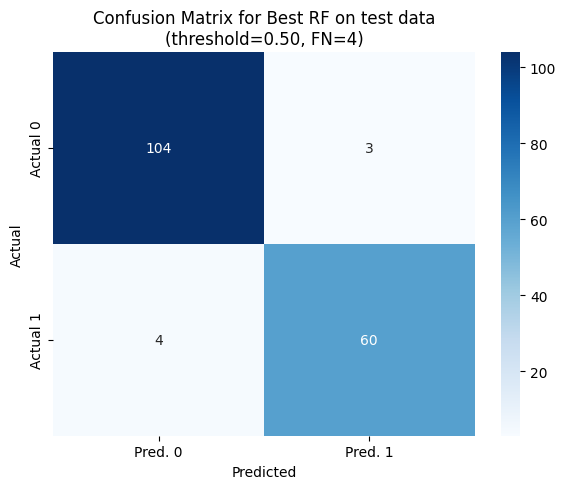

In [16]:
# Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. 0', 'Pred. 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Best RF on test data\n(threshold={final_threshold:.2f}, FN={final_cm[1,0]})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()